# YOLO — Session 1 Lab: Object Detection
### ITI · Instructor: Ahmed Abdelsalam

Hands-on with YOLO: detect objects in images, read the results, filter them, and count.

**Rules of the lab**
- Made for **Google Colab**.
- Try first, ask second.
- Done early? Head to the **Challenges**.

## Setup — run this first

In [1]:
!pip install ultralytics -q

from ultralytics import YOLO
import matplotlib.pyplot as plt
from skimage import data
from PIL import Image

# save a few sample images to disk to detect on
Image.fromarray(data.coffee()).save("coffee.jpg")
Image.fromarray(data.astronaut()).save("person.jpg")
Image.fromarray(data.chelsea()).save("cat.jpg")

model = YOLO("yolo11n.pt")   # pretrained nano model
print("Ready. Model knows", len(model.names), "classes.")

Ready. Model knows 80 classes.


## Exercise 1 — Detect and visualise

1. Run `model` on `"coffee.jpg"`.
2. Use `.plot()` on the first result to get the annotated image.
3. Show it with matplotlib (remember `.plot()` returns **BGR**, so reverse the channels with `[:, :, ::-1]`).


image 1/1 /content/coffee.jpg: 448x640 1 cup, 1 dining table, 239.8ms
Speed: 8.9ms preprocess, 239.8ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)


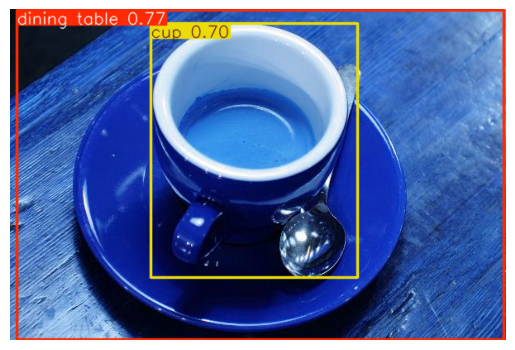

In [2]:
# Your code here
results = model("coffee.jpg")

plt.imshow(results[0].plot())
plt.axis("off")
plt.show()


## Exercise 2 — Read the detections

For `"coffee.jpg"`, loop over `results[0].boxes` and print, for each object:
`<label>  <confidence rounded to 2dp>  <box corners>`

Use `model.names[int(box.cls)]` for the label, `float(box.conf)` for confidence, and `box.xyxy[0]` for the corners.

In [3]:
# Your code here
results = model("coffee.jpg")

for box in results[0].boxes:

    label = model.names[int(box.cls)]
    confidence = float(box.conf)
    coordinates = box.xyxy.tolist()[0]

    print(label)
    print("Confidence:", confidence)
    print("Box:", coordinates)
    print()


image 1/1 /content/coffee.jpg: 448x640 1 cup, 1 dining table, 376.9ms
Speed: 13.9ms preprocess, 376.9ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)
dining table
Confidence: 0.7693042755126953
Box: [8.614883422851562, 1.6866873502731323, 597.8397827148438, 399.8912353515625]

cup
Confidence: 0.6980712413787842
Box: [170.77108764648438, 17.463655471801758, 420.478271484375, 324.52813720703125]



## Exercise 3 — Detect across several images

Loop over the three images `["coffee.jpg", "person.jpg", "cat.jpg"]`. For each one, print the filename and the list of labels YOLO found.


image 1/1 /content/coffee.jpg: 448x640 1 cup, 1 dining table, 307.0ms
Speed: 3.9ms preprocess, 307.0ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)


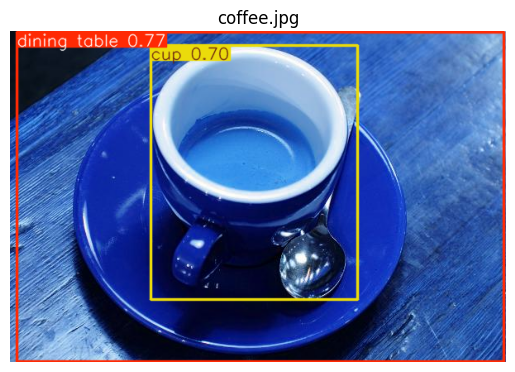


image 1/1 /content/person.jpg: 640x640 1 person, 1 sports ball, 248.3ms
Speed: 8.2ms preprocess, 248.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


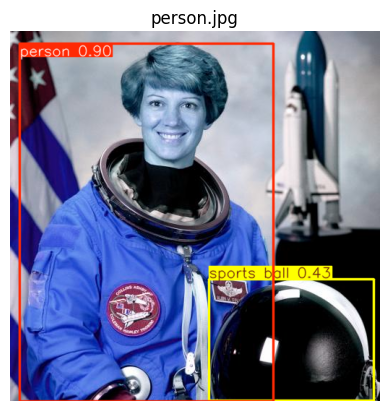

In [4]:
images = ["coffee.jpg", "person.jpg"]

for image in images:
    results = model(image)

    plt.imshow(results[0].plot())
    plt.title(image)
    plt.axis("off")
    plt.show()

## Exercise 4 — Filter by confidence

Run YOLO on `"coffee.jpg"`. Print only the detections whose confidence is **at least 0.6**, showing label and confidence.

In [5]:
# Your code here
results = model("coffee.jpg")

CONF_THRESHOLD = 0.7

for box in results[0].boxes:

    confidence = float(box.conf)

    if confidence >= CONF_THRESHOLD:

        label = model.names[int(box.cls)]

        print(label, confidence)


image 1/1 /content/coffee.jpg: 448x640 1 cup, 1 dining table, 240.8ms
Speed: 7.7ms preprocess, 240.8ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)
dining table 0.7693042755126953


## Exercise 5 — Count objects by class

Write a function `count_objects(image_path)` that returns a dictionary mapping each class name to how many times it appears in the image. Test it on `"coffee.jpg"`.

In [6]:
# Your code here
def count_objects(image_path):

    results = model(image_path)[0]

    counts = {}

    for box in results.boxes:

        label = model.names[int(box.cls)]

        counts[label] = counts.get(label, 0) + 1

    return counts


print(count_objects("coffee.jpg"))


image 1/1 /content/coffee.jpg: 448x640 1 cup, 1 dining table, 177.1ms
Speed: 4.3ms preprocess, 177.1ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)
{'dining table': 1, 'cup': 1}


## 🚀 Challenges

Add new cells as needed.

**Challenge A — Detect only one class.**
Use the `classes=[...]` argument to detect **only cups** in `coffee.jpg` (find the cup's class id from `model.names` first). Show the annotated result.


image 1/1 /content/coffee.jpg: 448x640 1 cup, 146.3ms
Speed: 3.8ms preprocess, 146.3ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)


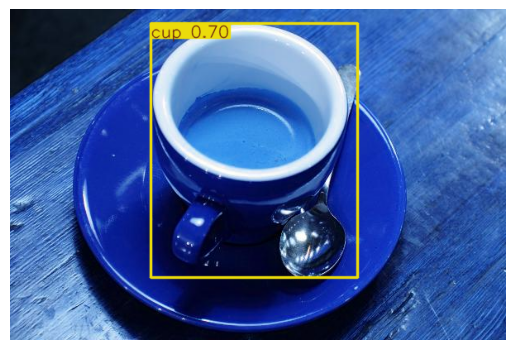

Number of cups: 1


In [7]:
# Your code here
cups = model("coffee.jpg", classes=[41])[0]

plt.imshow(cups.plot())
plt.axis("off")
plt.show()

print("Number of cups:", len(cups.boxes))


**Challenge B — Your own image.**
Upload a photo to Colab and run YOLO on it. Show the annotated image and print how many objects were found.

In [ ]:
# Your code here
from google.colab import files
from PIL import Image

uploaded = files.upload()

filename = next(iter(uploaded))

results = model(filename)

plt.imshow(results[0].plot())
plt.axis("off")
plt.show()

**Challenge C — Highest-confidence object.**
For `coffee.jpg`, find and print the single detection with the **highest** confidence (its label and score).

In [ ]:
# Your code here
results = model("coffee.jpg")[0]

best_box = max(results.boxes, key=lambda box: float(box.conf))

label = model.names[int(best_box.cls)]
confidence = float(best_box.conf)

print("Highest Confidence Object:")
print("Class:", label)
print("Confidence:", confidence)